In [2]:
import os
import pandas as pd
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms


In [3]:
class DDRDataset(Dataset):
    def __init__(self, csv_path, images_dir, transform=None):
        self.csv_path = csv_path
        self.images_dir = images_dir
        self.transform = transform

        # Load CSV
        df = pd.read_csv(csv_path)

        # Adjust these column names if needed after you open the CSV once
        self.image_names = df["id_code"].values      # or the correct column name
        self.labels = df["diagnosis"].values          # or "DR_grade" etc.

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        img_name = self.image_names[idx]
        label = self.labels[idx]

        img_path = os.path.join(self.images_dir, img_name)
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)


In [4]:
class DDRDataset(Dataset):
    def __init__(self, csv_path, images_dir, transform=None):
        self.csv_path = csv_path
        self.images_dir = images_dir
        self.transform = transform

        df = pd.read_csv(csv_path)

        # These two column names may need adjustment after we inspect CSV
        self.image_names = df["id_code"].values
        self.labels = df["diagnosis"].values

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        img_name = self.image_names[idx]
        label = self.labels[idx]

        img_path = os.path.join(self.images_dir, img_name)
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)


In [5]:
images_dir_ddr = "/Users/sabarish/Desktop/DR_DATA/DDR dataset/DR_grading/DR_grading"
csv_ddr = "/Users/sabarish/Desktop/DR_DATA/DDR dataset/DR_grading.csv"

transform_ddr = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

ddr_dataset = DDRDataset(csv_path=csv_ddr, images_dir=images_dir_ddr, transform=transform_ddr)
ddr_loader = DataLoader(ddr_dataset, batch_size=4, shuffle=True)

images, labels = next(iter(ddr_loader))
print("Images shape:", images.shape)
print("Labels:", labels)


Images shape: torch.Size([4, 3, 512, 512])
Labels: tensor([0, 2, 0, 0])


In [6]:
class EOpthaEXDataset(Dataset):
    def __init__(self, images_dir, masks_dir, image_transform=None, mask_transform=None):
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.image_transform = image_transform
        self.mask_transform = mask_transform

        # Sort to ensure image–mask alignment
        self.image_files = sorted(os.listdir(images_dir))
        self.mask_files = sorted(os.listdir(masks_dir))

        # Safety check
        assert len(self.image_files) == len(self.mask_files), \
            "❌ Number of images and masks do NOT match!"

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        mask_name = self.mask_files[idx]

        img_path = os.path.join(self.images_dir, img_name)
        mask_path = os.path.join(self.masks_dir, mask_name)

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")  # grayscale mask

        if self.image_transform:
            image = self.image_transform(image)

        if self.mask_transform:
            mask = self.mask_transform(mask)

        # Ensure mask is binary (0 or 1)
        mask = (mask > 0.5).float()

        return image, mask


In [ ]:
eophtha_images_dir = "/Users/sabarish/Desktop/DR_DATA/EOptha Diabetic Retinopathy/EOptha Diabetic Retinopathy/EX"
eophtha_masks_dir  = "/Users/sabarish/Desktop/DR_DATA/EOptha Diabetic Retinopathy/EOptha Diabetic Retinopathy/Annotation_EX"

image_transform = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

mask_transform = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor()
])

eophtha_dataset = EOpthaEXDataset(
    images_dir=eophtha_images_dir,
    masks_dir=eophtha_masks_dir,
    image_transform=image_transform,
    mask_transform=mask_transform
)

eophtha_loader = DataLoader(
    eophtha_dataset,
    batch_size=4,
    shuffle=True
)


In [8]:
images, masks = next(iter(eophtha_loader))

print("Images shape:", images.shape)   # should be [4, 3, 512, 512]
print("Masks shape:", masks.shape)     # should be [4, 1, 512, 512]
print("Mask min/max:", masks.min().item(), masks.max().item())


Images shape: torch.Size([4, 3, 512, 512])
Masks shape: torch.Size([4, 1, 512, 512])
Mask min/max: 0.0 1.0


In [9]:

class IDRiDDataset(Dataset):
    def __init__(self, csv_path, images_dir, transform=None):
        self.csv_path = csv_path
        self.images_dir = images_dir
        self.transform = transform

        df = pd.read_csv(csv_path)
        print("CSV columns:", df.columns.tolist())  # should show ['id_code','diagnosis','Risk of macular edema']

        # Use only these two columns
        self.id_codes = df["id_code"].values              # e.g. 'IDRiD_001'
        self.labels = df["diagnosis"].values.astype(int)  # DR grade

    def __len__(self):
        return len(self.id_codes)

    def __getitem__(self, idx):
        img_id = self.id_codes[idx]   # e.g. "IDRiD_001"
        label = self.labels[idx]

        # Try common extensions
        possible_exts = [".png", ".jpg", ".jpeg"]
        img_path = None
        for ext in possible_exts:
            candidate = os.path.join(self.images_dir, img_id + ext)
            if os.path.exists(candidate):
                img_path = candidate
                break

        if img_path is None:
            raise FileNotFoundError(f"No image found for ID {img_id} in {self.images_dir}")

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)


In [10]:
class DRFolderDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        """
        root_dir: path to train/ or val/ or test/ which contains subfolders 0,1,2,3,4
        """
        self.root_dir = root_dir
        self.transform = transform

        # find class folders (0,1,2,3,4)
        self.classes = sorted(
            [d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))]
        )
        self.class_to_idx = {cls_name: idx for idx, cls_name in enumerate(self.classes)}

        self.samples = []  # (image_path, label_idx)

        valid_exts = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp")

        for cls_name in self.classes:
            cls_dir = os.path.join(root_dir, cls_name)
            for fname in os.listdir(cls_dir):
                if fname.lower().endswith(valid_exts):
                    path = os.path.join(cls_dir, fname)
                    label = self.class_to_idx[cls_name]
                    self.samples.append((path, label))

        if len(self.samples) == 0:
            raise RuntimeError(f"No valid images found in {root_dir}")

        print(f"[DRFolderDataset] root={root_dir}")
        print(f"  classes: {self.classes}")
        print(f"  num samples: {len(self.samples)}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label


In [11]:
from torchvision import transforms
from torch.utils.data import DataLoader

base_root = "/Users/sabarish/Desktop/DR_DATA/Eyepacs, Aptos, Messidor Diabetic Retinopathy"
eye_base = os.path.join(base_root, "augmented_resized_V2")

train_dir = os.path.join(eye_base, "train")
val_dir   = os.path.join(eye_base, "val")
test_dir  = os.path.join(eye_base, "test")

common_transform = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset = DRFolderDataset(train_dir, transform=common_transform)
val_dataset   = DRFolderDataset(val_dir,   transform=val_test_transform)
test_dataset  = DRFolderDataset(test_dir,  transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=8, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=8, shuffle=False)

print("Train classes:", train_dataset.classes)
print("Class → idx:", train_dataset.class_to_idx)
print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))
print("Test samples:", len(test_dataset))


[DRFolderDataset] root=/Users/sabarish/Desktop/DR_DATA/Eyepacs, Aptos, Messidor Diabetic Retinopathy/augmented_resized_V2/train
  classes: ['0', '1', '2', '3', '4']
  num samples: 115241
[DRFolderDataset] root=/Users/sabarish/Desktop/DR_DATA/Eyepacs, Aptos, Messidor Diabetic Retinopathy/augmented_resized_V2/val
  classes: ['0', '1', '2', '3', '4']
  num samples: 14227
[DRFolderDataset] root=/Users/sabarish/Desktop/DR_DATA/Eyepacs, Aptos, Messidor Diabetic Retinopathy/augmented_resized_V2/test
  classes: ['0', '1', '2', '3', '4']
  num samples: 14201
Train classes: ['0', '1', '2', '3', '4']
Class → idx: {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4}
Train samples: 115241
Val samples: 14227
Test samples: 14201


In [12]:
images, labels = next(iter(train_loader))
print("Batch images shape:", images.shape)
print("Batch labels:", labels)


Batch images shape: torch.Size([8, 3, 512, 512])
Batch labels: tensor([2, 2, 0, 3, 0, 1, 2, 2])


In [13]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

num_classes = len(train_dataset.classes)  # should be 5

model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


Using device: cpu
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /Users/sabarish/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:14<00:00, 6.98MB/s]


In [14]:
from tqdm.auto import tqdm

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, desc="Train", leave=False):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, desc="Eval", leave=False):
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


/opt/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [18]:
import torch

if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("✅ Using Apple MPS GPU")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("✅ Using CUDA GPU")
else:
    device = torch.device("cpu")
    print("⚠️ Using CPU (no GPU found)")


✅ Using Apple MPS GPU


In [19]:
import os
from torch.utils.data import DataLoader, Subset
from torchvision import transforms

# Base folder on your Mac
base_root = "/Users/sabarish/Desktop/DR_DATA/Eyepacs, Aptos, Messidor Diabetic Retinopathy"
eye_base  = os.path.join(base_root, "augmented_resized_V2")

train_dir = os.path.join(eye_base, "train")
val_dir   = os.path.join(eye_base, "val")
test_dir  = os.path.join(eye_base, "test")

print("Train dir:", train_dir)
print("Val dir:",   val_dir)
print("Test dir:",  test_dir)


Train dir: /Users/sabarish/Desktop/DR_DATA/Eyepacs, Aptos, Messidor Diabetic Retinopathy/augmented_resized_V2/train
Val dir: /Users/sabarish/Desktop/DR_DATA/Eyepacs, Aptos, Messidor Diabetic Retinopathy/augmented_resized_V2/val
Test dir: /Users/sabarish/Desktop/DR_DATA/Eyepacs, Aptos, Messidor Diabetic Retinopathy/augmented_resized_V2/test


In [20]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


In [21]:
from PIL import Image
from torch.utils.data import Dataset

class DRFolderDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform

        self.classes = sorted(
            [d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))]
        )
        self.class_to_idx = {cls_name: idx for idx, cls_name in enumerate(self.classes)}

        self.samples = []
        valid_exts = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp")

        for cls_name in self.classes:
            cls_dir = os.path.join(root_dir, cls_name)
            for fname in os.listdir(cls_dir):
                if fname.lower().endswith(valid_exts):
                    path = os.path.join(cls_dir, fname)
                    label = self.class_to_idx[cls_name]
                    self.samples.append((path, label))

        if len(self.samples) == 0:
            raise RuntimeError(f"No valid images found in {root_dir}")

        print(f"[DRFolderDataset] root={root_dir}")
        print(f"  classes: {self.classes}")
        print(f"  num samples: {len(self.samples)}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label

# build datasets
train_dataset_full = DRFolderDataset(train_dir, transform=train_transform)
val_dataset        = DRFolderDataset(val_dir,   transform=val_test_transform)
test_dataset       = DRFolderDataset(test_dir,  transform=val_test_transform)


[DRFolderDataset] root=/Users/sabarish/Desktop/DR_DATA/Eyepacs, Aptos, Messidor Diabetic Retinopathy/augmented_resized_V2/train
  classes: ['0', '1', '2', '3', '4']
  num samples: 115241
[DRFolderDataset] root=/Users/sabarish/Desktop/DR_DATA/Eyepacs, Aptos, Messidor Diabetic Retinopathy/augmented_resized_V2/val
  classes: ['0', '1', '2', '3', '4']
  num samples: 14227
[DRFolderDataset] root=/Users/sabarish/Desktop/DR_DATA/Eyepacs, Aptos, Messidor Diabetic Retinopathy/augmented_resized_V2/test
  classes: ['0', '1', '2', '3', '4']
  num samples: 14201


In [22]:
import numpy as np
from torch.utils.data import Subset

subset_size = 5000  # you can lower to 2000 if needed
subset_size = min(subset_size, len(train_dataset_full))

indices = np.random.choice(len(train_dataset_full), subset_size, replace=False)
train_dataset = Subset(train_dataset_full, indices)

batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

print("Train subset size:", len(train_dataset))
print("Val size:", len(val_dataset))
print("Test size:", len(test_dataset))


Train subset size: 5000
Val size: 14227
Test size: 14201


In [26]:
import torch.nn as nn
from torchvision import models

# ✅ Always take classes from the FULL dataset (not the Subset)
num_classes = len(train_dataset_full.classes)
print("Num classes:", num_classes)

model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


Num classes: 5
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/sabarish/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:06<00:00, 7.04MB/s]


In [27]:
from tqdm.auto import tqdm

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, desc="Train", leave=False):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, desc="Eval", leave=False):
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


In [28]:
best_val_acc = 0.0
num_epochs = 3

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")

    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, criterion, device
    )
    val_loss, val_acc = evaluate(
        model, val_loader, criterion, device
    )

    print(f"Train loss: {train_loss:.4f} | acc: {train_acc:.4f}")
    print(f"Val   loss: {val_loss:.4f} | acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(
            model.state_dict(),
            "/Users/sabarish/Desktop/DR_DATA/baseline_resnet18_eye_subset.pth",
        )
        print("💾 Best baseline model saved.")



Epoch 1/3


Train loss: 1.0724 | acc: 0.5936
Val   loss: 0.9360 | acc: 0.6432
💾 Best baseline model saved.

Epoch 2/3


Train loss: 0.8680 | acc: 0.6712
Val   loss: 0.8548 | acc: 0.6783
💾 Best baseline model saved.

Epoch 3/3


Train loss: 0.7672 | acc: 0.7064
Val   loss: 0.9192 | acc: 0.6811
💾 Best baseline model saved.


In [29]:
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"\n✅ Fast baseline TEST accuracy: {test_acc:.4f}")



✅ Fast baseline TEST accuracy: 0.6066


In [30]:
import torch
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = outputs.max(1)

        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

print("Confusion matrix:")
print(confusion_matrix(all_labels, all_preds))

print("\nClassification report:")
print(classification_report(all_labels, all_preds))


Confusion matrix:
[[6678  157   50    2    9]
 [ 978  649  205   11   19]
 [1184 1057  313  215  230]
 [  82  226  124  220  326]
 [ 152  230  143  186  755]]

Classification report:
              precision    recall  f1-score   support

           0       0.74      0.97      0.84      6896
           1       0.28      0.35      0.31      1862
           2       0.37      0.10      0.16      2999
           3       0.35      0.22      0.27       978
           4       0.56      0.52      0.54      1466

    accuracy                           0.61     14201
   macro avg       0.46      0.43      0.42     14201
weighted avg       0.56      0.61      0.56     14201



In [31]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torchvision.transforms.functional import to_pil_image


In [33]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer

        self.activations = None
        self.gradients = None

        # forward hook: save feature maps
        self.fwd_hook = target_layer.register_forward_hook(self.save_activation)
        # backward hook: save gradients
        self.bwd_hook = target_layer.register_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output.detach()

    def save_gradient(self, module, grad_input, grad_output):
        # grad_output is a tuple; we want grad wrt activations
        self.gradients = grad_output[0].detach()

    def __call__(self, input_tensor, target_class=None):
        """
        input_tensor: (1, 3, H, W) on device
        target_class: int or None (if None, uses predicted class)
        """
        self.model.zero_grad()
        output = self.model(input_tensor)  # (1, num_classes)

        if target_class is None:
            target_class = output.argmax(dim=1).item()

        score = output[0, target_class]
        score.backward()

        # activations: (1, C, h, w)
        # gradients:   (1, C, h, w)
        grads = self.gradients          # (1, C, h, w)
        acts  = self.activations        # (1, C, h, w)

        # global-average-pool the gradients over spatial dims
        weights = grads.mean(dim=(2, 3), keepdim=True)  # (1, C, 1, 1)

        # weighted sum of activations
        cam = (weights * acts).sum(dim=1, keepdim=True)  # (1, 1, h, w)

        cam = F.relu(cam)

        # normalize to [0, 1]
        cam -= cam.min()
        if cam.max() > 0:
            cam /= cam.max()

        return cam  # (1, 1, h, w)

    def remove_hooks(self):
        self.fwd_hook.remove()
        self.bwd_hook.remove()


In [34]:
model.eval()
target_layer = model.layer4[-1]  # last BasicBlock
gradcam = GradCAM(model, target_layer)


In [35]:
images, labels = next(iter(test_loader))  # images: (B,3,H,W)
idx = 0  # pick first image in batch

img = images[idx:idx+1].to(device)  # shape (1,3,H,W)
label = labels[idx].item()

# Get Grad-CAM heatmap (same spatial size as conv feature map, not input yet)
cam = gradcam(img)  # (1,1,h,w)


/opt/miniconda3/lib/python3.13/site-packages/torch/nn/modules/module.py:1866: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


In [36]:
cam_up = F.interpolate(cam, size=img.shape[-2:], mode="bilinear", align_corners=False)
cam_up = cam_up[0, 0].cpu().numpy()  # (H, W)


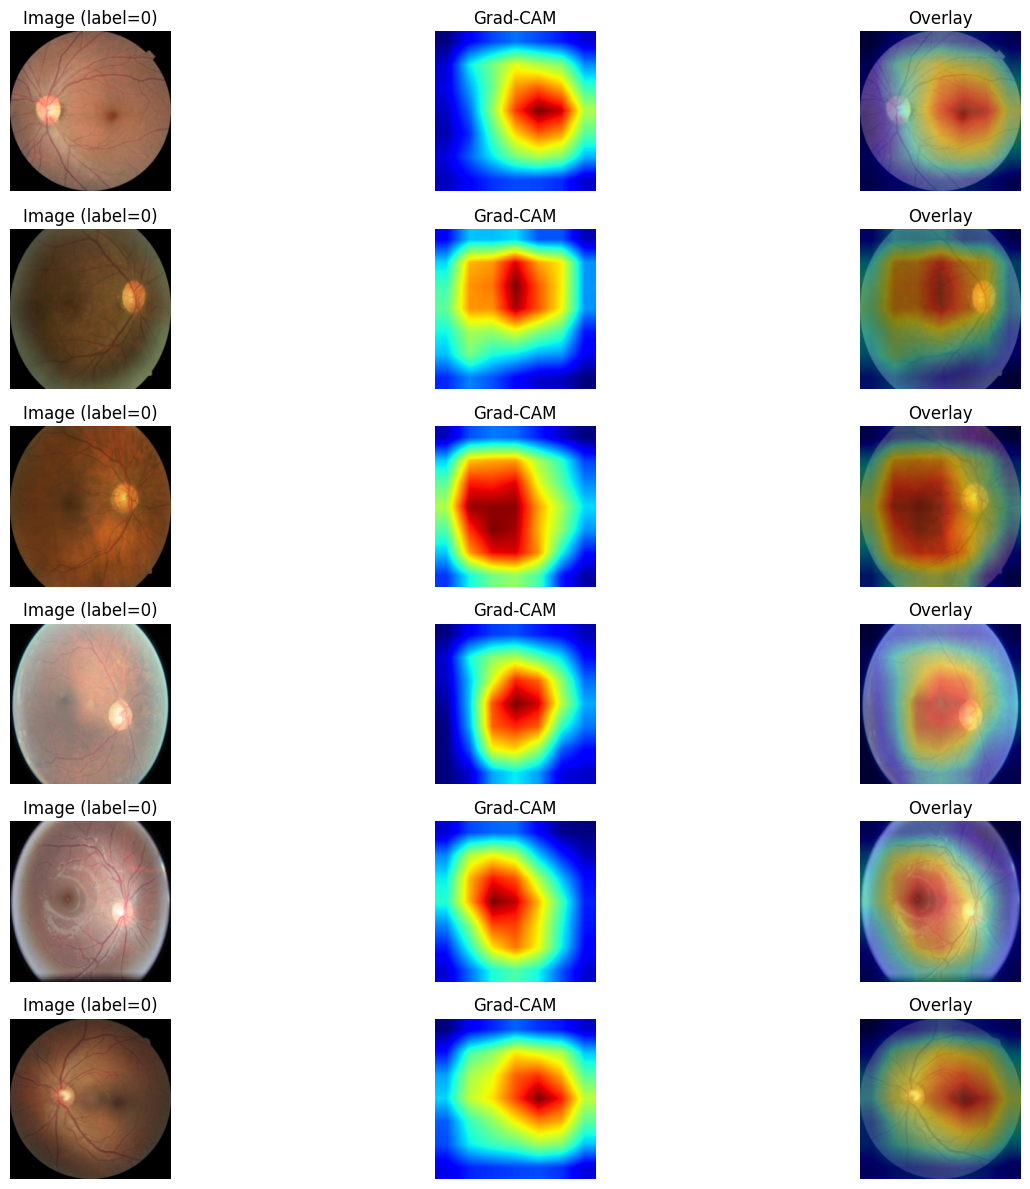

In [38]:
images, labels = next(iter(test_loader))

num_show = 6  # number of images to display
model.eval()

plt.figure(figsize=(15, 12))

for idx in range(num_show):
    img = images[idx:idx+1].to(device)
    label = labels[idx].item()

    cam = gradcam(img)
    cam_up = F.interpolate(
        cam, size=img.shape[-2:], mode="bilinear", align_corners=False
    )
    cam_up = cam_up[0, 0].cpu().numpy()

    # Unnormalize for display
    img_cpu = img[0].cpu().clone()
    img_cpu[0] = img_cpu[0] * 0.229 + 0.485
    img_cpu[1] = img_cpu[1] * 0.224 + 0.456
    img_cpu[2] = img_cpu[2] * 0.225 + 0.406
    img_cpu = torch.clamp(img_cpu, 0, 1)

    img_pil = to_pil_image(img_cpu)

    # ---- PLOTTING ----
    plt.subplot(num_show, 3, idx * 3 + 1)
    plt.imshow(img_pil)
    plt.title(f"Image (label={label})")
    plt.axis("off")

    plt.subplot(num_show, 3, idx * 3 + 2)
    plt.imshow(cam_up, cmap="jet")
    plt.title("Grad-CAM")
    plt.axis("off")

    plt.subplot(num_show, 3, idx * 3 + 3)
    plt.imshow(img_pil)
    plt.imshow(cam_up, cmap="jet", alpha=0.4)
    plt.title("Overlay")
    plt.axis("off")

plt.tight_layout()
plt.show()


In [41]:
import os

DATA_ROOT = "/Users/sabarish/Desktop/DR_DATA"

# 1. EyePACS + APTOS + Messidor (for grading)
EYE_ROOT = os.path.join(DATA_ROOT, "Eyepacs, Aptos, Messidor Diabetic Retinopathy", "augmented_resized_V2")
EYE_TRAIN = os.path.join(EYE_ROOT, "train")
EYE_VAL   = os.path.join(EYE_ROOT, "val")
EYE_TEST  = os.path.join(EYE_ROOT, "test")

print("Eye train:", EYE_TRAIN)
print("Eye val  :", EYE_VAL)
print("Eye test :", EYE_TEST)

# 2. IDRiD grading (images + csv)
IDRID_ROOT = os.path.join(
    DATA_ROOT,
    "IDRiD - Diabetic Retinopathy - Grading",
    "IDRiD - Diabetic Retinopathy - Grading"
)
IDRID_IMAGES = os.path.join(IDRID_ROOT, "Imagenes", "Imagenes")
IDRID_CSV    = os.path.join(IDRID_ROOT, "idrid_labels.csv")

print("IDRiD images:", IDRID_IMAGES)
print("IDRiD csv   :", IDRID_CSV)

# 3. e-Ophtha EX (images + lesion masks)
EOPHTHA_ROOT  = os.path.join(DATA_ROOT, "EOptha Diabetic Retinopathy", "EOptha Diabetic Retinopathy")
EOPHTHA_IMG   = os.path.join(EOPHTHA_ROOT, "EX")
EOPHTHA_MASKS = os.path.join(EOPHTHA_ROOT, "Annotation_EX")

print("e-Ophtha images:", EOPHTHA_IMG)
print("e-Ophtha masks :", EOPHTHA_MASKS)


Eye train: /Users/sabarish/Desktop/DR_DATA/Eyepacs, Aptos, Messidor Diabetic Retinopathy/augmented_resized_V2/train
Eye val  : /Users/sabarish/Desktop/DR_DATA/Eyepacs, Aptos, Messidor Diabetic Retinopathy/augmented_resized_V2/val
Eye test : /Users/sabarish/Desktop/DR_DATA/Eyepacs, Aptos, Messidor Diabetic Retinopathy/augmented_resized_V2/test
IDRiD images: /Users/sabarish/Desktop/DR_DATA/IDRiD - Diabetic Retinopathy - Grading/IDRiD - Diabetic Retinopathy - Grading/Imagenes/Imagenes
IDRiD csv   : /Users/sabarish/Desktop/DR_DATA/IDRiD - Diabetic Retinopathy - Grading/IDRiD - Diabetic Retinopathy - Grading/idrid_labels.csv
e-Ophtha images: /Users/sabarish/Desktop/DR_DATA/EOptha Diabetic Retinopathy/EOptha Diabetic Retinopathy/EX
e-Ophtha masks : /Users/sabarish/Desktop/DR_DATA/EOptha Diabetic Retinopathy/EOptha Diabetic Retinopathy/Annotation_EX


In [52]:
import os
from PIL import Image
from torch.utils.data import Dataset
import torch

class EOphthaLesionDataset(Dataset):
    """
    e-Ophtha EX:
      images: EX1.jpg, EX2.jpg, ...
      masks : EX_GT1.png, EX_GT2.png, ...
    Returns: (image_tensor, mask_tensor) with shapes (3,224,224) and (1,224,224)
    """
    def __init__(self, img_dir, mask_dir, img_transform=None, mask_transform=None):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.img_transform = img_transform
        self.mask_transform = mask_transform

        img_files = sorted([
            f for f in os.listdir(img_dir)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ])

        self.pairs = []

        for f in img_files:
            base = os.path.splitext(f)[0]   # e.g. "EX1"
            # extract numeric part: "1" from "EX1"
            num = "".join(ch for ch in base if ch.isdigit())

            if num == "":
                # skip weird files
                continue

            # try common mask extensions
            mask_candidate = None
            for ext in [".png", ".jpg", ".jpeg"]:
                mname = f"EX_GT{num}{ext}"
                mpath = os.path.join(mask_dir, mname)
                if os.path.exists(mpath):
                    mask_candidate = mpath
                    break

            if mask_candidate is not None:
                self.pairs.append((
                    os.path.join(img_dir, f),
                    mask_candidate
                ))

        if len(self.pairs) == 0:
            raise RuntimeError(
                f"No image–mask pairs found. Check naming under {img_dir} and {mask_dir}."
            )

        print(f"[EOphtha] matched {len(self.pairs)} image–mask pairs.")

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]

        img = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")   # grayscale

        if self.img_transform:
            img = self.img_transform(img)
        if self.mask_transform:
            mask = self.mask_transform(mask)

        # binarize mask to {0,1}
        mask = (mask > 0.5).float()

        return img, mask


In [53]:
lesion_img_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

lesion_mask_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])


In [54]:
from torch.utils.data import DataLoader

EOPHTHA_IMG   = "/Users/sabarish/Desktop/DR_DATA/EOptha Diabetic Retinopathy/EOptha Diabetic Retinopathy/EX"
EOPHTHA_MASKS = "/Users/sabarish/Desktop/DR_DATA/EOptha Diabetic Retinopathy/EOptha Diabetic Retinopathy/Annotation_EX"

eophtha_dataset = EOphthaLesionDataset(
    EOPHTHA_IMG,
    EOPHTHA_MASKS,
    img_transform=lesion_img_transform,
    mask_transform=lesion_mask_transform
)

eophtha_loader = DataLoader(eophtha_dataset, batch_size=4, shuffle=True)

imgs, masks = next(iter(eophtha_loader))
print("Images:", imgs.shape)   # expected: [4, 3, 224, 224]
print("Masks :", masks.shape)  # expected: [4, 1, 224, 224]


[EOphtha] matched 47 image–mask pairs.
Images: torch.Size([4, 3, 224, 224])
Masks : torch.Size([4, 1, 224, 224])


In [55]:
target_layer = model.layer4[-1]  # last conv block in ResNet18
gradcam = GradCAM(model, target_layer)
model.eval()


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [56]:
import torch.nn.functional as F
import torch

def normalize_cam_batch(cam_batch):
    """
    cam_batch: (B,1,H,W), raw Grad-CAM values
    returns:   (B,1,H,W) normalized to [0,1]
    """
    cam_batch = F.relu(cam_batch)
    cam_min = cam_batch.amin(dim=(2,3), keepdim=True)
    cam_max = cam_batch.amax(dim=(2,3), keepdim=True)
    cam_norm = (cam_batch - cam_min) / (cam_max - cam_min + 1e-8)
    return cam_norm

def explanation_alignment_loss(cam_batch, mask_batch):
    """
    cam_batch : (B,1,H,W) Grad-CAM heatmaps
    mask_batch: (B,1,H,W) binary lesion masks (0/1)
    """
    cam_norm = normalize_cam_batch(cam_batch)
    mask_bin = (mask_batch > 0.5).float()
    loss = F.binary_cross_entropy(cam_norm, mask_bin)
    return loss


In [57]:
# one batch from e-Ophtha
imgs, masks = next(iter(eophtha_loader))   # imgs: [B,3,224,224], masks: [B,1,224,224]
imgs  = imgs.to(device)
masks = masks.to(device)

model.eval()

cams_up_list = []

for i in range(imgs.size(0)):
    img_i = imgs[i:i+1]  # (1,3,H,W)

    # Grad-CAM call (target_class=None → uses predicted class)
    cam = gradcam(img_i)  # (1,1,h,w)

    # Upsample to input size
    cam_up = F.interpolate(
        cam,
        size=img_i.shape[-2:],
        mode="bilinear",
        align_corners=False
    )  # (1,1,H,W)

    cams_up_list.append(cam_up)

cam_batch = torch.cat(cams_up_list, dim=0)  # (B,1,H,W)

loss_explain = explanation_alignment_loss(cam_batch, masks)
print("Explanation alignment loss on this batch:", loss_explain.item())


Explanation alignment loss on this batch: 0.6196930408477783
